In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, PercentFormatter)
from matplotlib.lines import Line2D

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import CompareModels, ModelEvaluator
from scripts.plot_function import *
#from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 
plot_path = 'M:\\1confiProj\\Analysis\\output'

device is : cpu


## Model simulation

In [2]:
m_label = 'with_dn'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim = pd.concat(df_sim_lst, ignore_index=True)

#df_beh = ev.dh.get_allsub_beh_data()

Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  2.98subject/s]


In [12]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,bias,flipBias,abs_delta_VA,bias_abs,bias_abs_rel,bias_rel,bias_abs_zscore,bias_zscore,CISize_zscore,m_id
0,-10.0,-10.0,1.0,1.0,-6.450819,4.634591,1.0,58.0,2,0.0,...,1.697147,1.697147,0.0,3.549181,inf,inf,0.712245,0.394475,-0.718297,2
1,-10.0,-10.0,1.0,1.0,-9.426065,4.883371,1.0,95.0,2,0.0,...,-1.278099,-1.278099,0.0,0.573935,inf,-inf,0.114169,-0.309652,-0.545556,2
2,-10.0,-10.0,1.0,1.0,-10.164258,5.098824,1.0,83.0,2,0.0,...,-2.016292,-2.016292,0.0,-0.164258,-inf,-inf,-0.034220,-0.484354,-0.395957,2
3,-10.0,-10.0,1.0,1.0,-3.657926,4.467601,1.0,29.0,2,0.0,...,4.490041,4.490041,0.0,6.342074,inf,inf,1.273665,1.055447,-0.834246,2
4,-10.0,-10.0,1.0,1.0,-1.627839,8.251496,2.0,61.0,2,0.0,...,6.520128,6.520128,0.0,8.372161,inf,inf,1.681747,1.535891,1.793099,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795924,10.0,10.0,2.0,0.0,14.029883,8.885800,1.0,97.0,25,0.0,...,6.793384,6.793384,0.0,4.029883,inf,inf,0.760034,1.576119,-0.504640,2
795925,10.0,10.0,2.0,0.0,8.313199,10.121153,1.0,91.0,25,0.0,...,1.076699,1.076699,0.0,-1.686801,-inf,inf,-0.329707,0.252705,0.211174,2
795926,10.0,10.0,2.0,0.0,2.613086,9.741423,1.0,98.0,25,0.0,...,-4.623414,-4.623414,0.0,-7.386914,-inf,-inf,-1.416289,-1.066873,-0.008858,2
795927,10.0,10.0,2.0,0.0,10.920332,9.382868,1.0,99.0,25,0.0,...,3.683832,3.683832,0.0,0.920332,inf,inf,0.167277,0.856257,-0.216619,2


In [4]:
df_beh

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,mean,bias,flipBias,abs_delta_VA,bias_abs,bias_abs_rel,bias_rel,flipBias_abs,bias_abs_zscore,CISize_zscore
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,...,5.146216,-10.076216,10.076216,15.0,-9.93,0.662000,0.671748,9.93,-1.798937,-0.331626
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,...,-8.312162,13.242162,13.242162,20.0,14.93,0.746500,0.662108,14.93,2.319995,-0.460572
2,-5.0,-10.0,1.0,1.0,-5.94,5.56,1.0,39.0,2,-5.0,...,-4.934054,-1.005946,1.005946,5.0,-0.94,0.188000,0.201189,0.94,-0.309428,0.156129
3,-5.0,5.0,1.0,1.0,4.38,2.01,1.0,78.0,2,10.0,...,-4.934054,9.314054,9.314054,10.0,9.38,0.938000,0.931405,9.38,1.400442,-1.834135
4,-5.0,-5.0,1.0,1.0,-3.82,2.91,1.0,88.0,2,0.0,...,-4.934054,1.114054,1.114054,0.0,1.18,inf,inf,1.18,0.041825,-1.329561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19427,5.0,-10.0,2.0,0.0,-6.94,9.95,2.0,84.0,25,-15.0,...,-7.918333,0.978333,-0.978333,15.0,-11.94,0.796000,-0.065222,11.94,-1.326974,0.045977
19428,-10.0,5.0,2.0,0.0,5.83,8.22,2.0,100.0,25,15.0,...,5.925833,-0.095833,-0.095833,15.0,15.83,1.055333,-0.006389,15.83,1.700414,-0.396073
19429,10.0,5.0,2.0,0.0,5.94,11.75,1.0,100.0,25,-5.0,...,5.925833,0.014167,-0.014167,5.0,-4.06,0.812000,-0.002833,4.06,-0.467924,0.505913
19430,-5.0,-5.0,2.0,0.0,-5.60,11.77,1.0,100.0,25,0.0,...,-5.005833,-0.594167,-0.594167,0.0,-0.60,-inf,-inf,-0.60,-0.090727,0.511023


## Raw localization

In [3]:
df_plot = df_sim[(df_sim['Modality'] == 'A')]
all_summary_sub = (
    df_plot
    .groupby(["AudLoc", "VisLoc", "sub_id", 'VisRelLabel', 'Sources'])
    .agg(n=('RespLoc', "size"))
    .reset_index()
)

all_summary = (
    all_summary_sub
    .groupby(["AudLoc", "VisLoc", 'VisRelLabel', 'Sources'])
    .agg(n=("n", "sum"))
    .reset_index()
)

# power = 1.5
# global_n = np.power(all_summary["n"], power)

global_min = all_summary["n"].min()
global_max = all_summary["n"].max()
global_min, global_max

(np.int64(651), np.int64(7228))

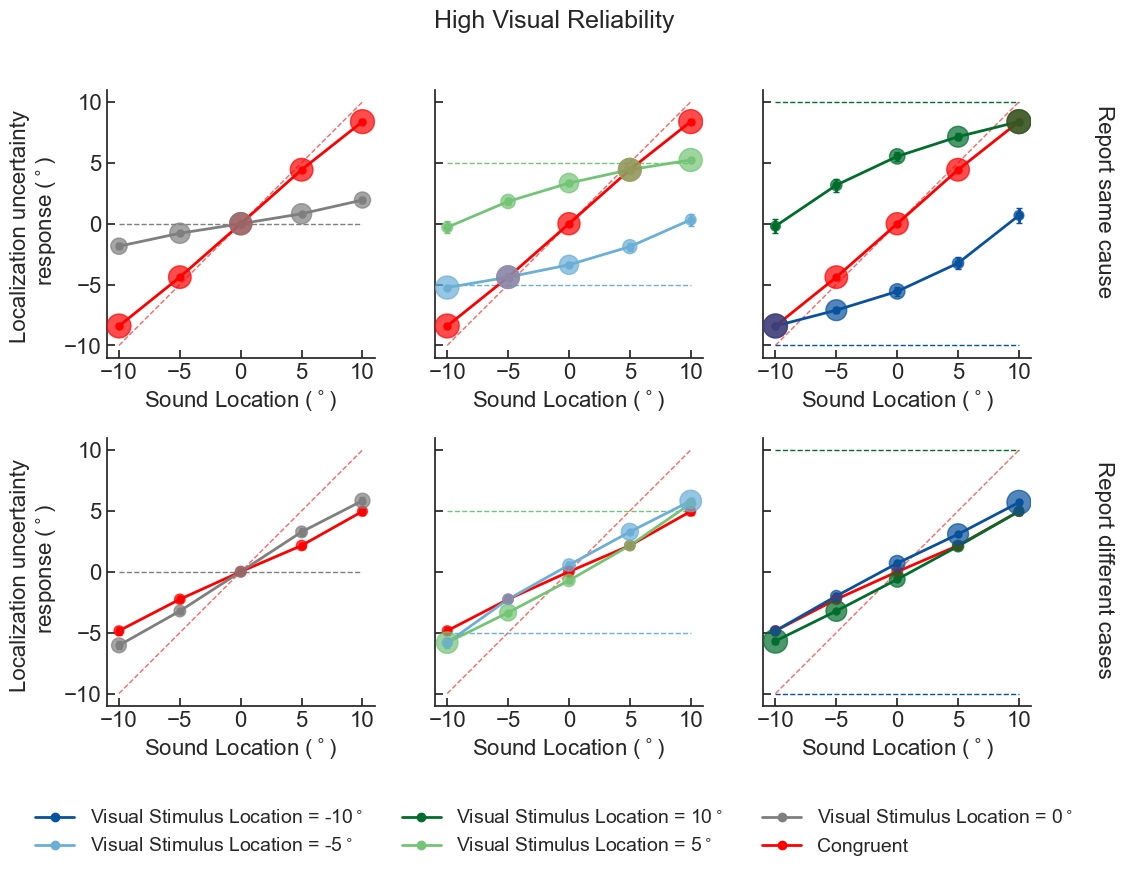

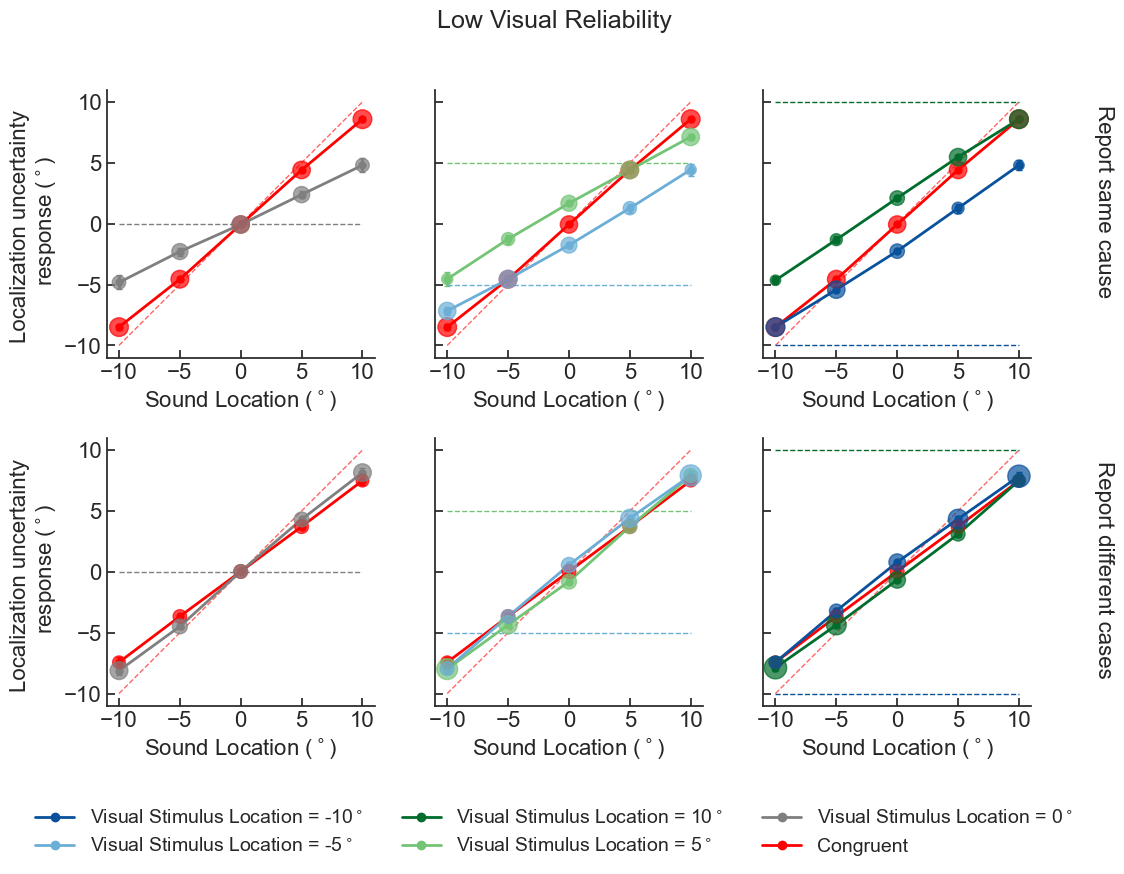

In [4]:

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_sim.loc[df_sim.Sources == sources],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    #plt.savefig(os.path.join(plot_path,'Raw_loc', f'Allsub_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

## Plot CI


In [5]:
def plot_CI_size_by_condition(df, m_id=None, axs=None, Modality='A', loc_var = 'AudLoc'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', loc_var]).CISize.mean().reset_index()
    palette = sns.color_palette("viridis", as_cmap=False)

    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'High'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[0],
        legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
    )
    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'Low'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[1],
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        #legend = None,
    )
    clean_axs(axs[0])
    clean_axs(axs[1])
    axs[0].set_xlabel('')
    axs[1].set_xlabel('')
    axs[1].legend(
        title='Absolute spatial disparity ($^\\circ$)',
        frameon=False,
        loc='lower center',
        ncol=5,
        bbox_to_anchor=(0, -0.5),
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )
    # axs[0].set_title('High visual reliability', fontsize=fontsize)
    # axs[1].set_title('Low visual reliability', fontsize=fontsize)
    # axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
    # axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
    # axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


C:\Users\wenlou\AppData\Local\Temp\ipykernel_23236\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_23236\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


Text(0.5, 0, 'Sound location ($^\\circ$)')

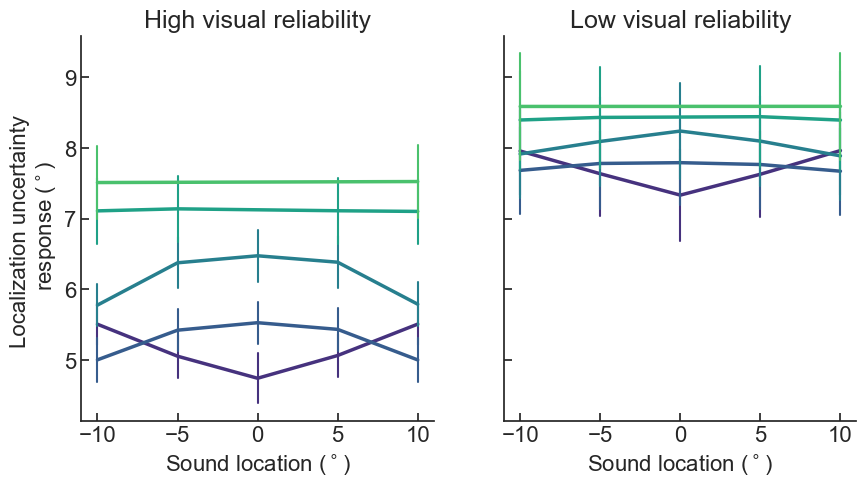

In [9]:
fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)

# axs[0,0].set_xlabel('')
# axs[0,1].set_xlabel('')
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs) 
#axs[0,1].legend('')
#plot_CI_size_by_condition(df=df_beh, axs=axs[0,:]) 
axs[1].get_legend().remove()
axs[0].set_title('High visual reliability', fontsize=fontsize+2)
axs[1].set_title('Low visual reliability', fontsize=fontsize+2)
axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
axs[0].set_xlabel('Sound location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Sound location ($^\\circ$)', fontsize=fontsize)
#fig.supylabel('Localization uncertainty report', fontsize=fontsize+2)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_32216\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_32216\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_32216\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_32216\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


Text(0.5, 0.98, 'Visual modality')

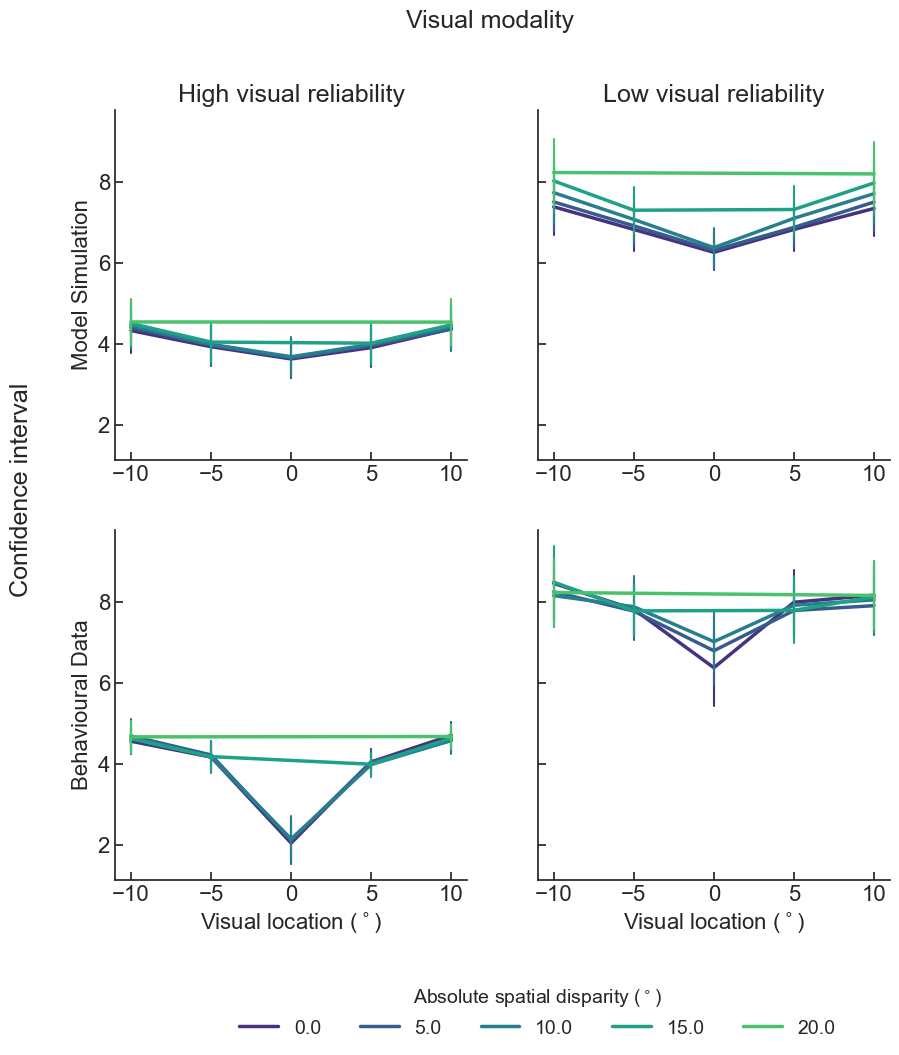

In [66]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)

# axs[0,0].set_xlabel('')
# axs[0,1].set_xlabel('')
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs[0,:], Modality='V', loc_var='VisLoc') 
#axs[0,1].legend('')
axs[0,1].get_legend().remove()
plot_CI_size_by_condition(df=df_beh, axs=axs[1,:], Modality='V', loc_var='VisLoc') 
axs[0,0].set_title('High visual reliability', fontsize=fontsize+2)
axs[0,1].set_title('Low visual reliability', fontsize=fontsize+2)
axs[0,0].set_ylabel('Model Simulation', fontsize=fontsize)
axs[1,0].set_ylabel('Behavioural Data', fontsize=fontsize)
axs[1,0].set_xlabel('Visual location ($^\\circ$)', fontsize=fontsize)
axs[1,1].set_xlabel('Visual location ($^\\circ$)', fontsize=fontsize)
fig.supylabel('Confidence interval', fontsize=fontsize+2)
fig.suptitle('Visual modality', fontsize=fontsize+2)
#fig.tight_layout()

In [67]:
#define color scheme.
palette_beh= {'High': '#4C72B0', 'Low': '#DD8452'}
palette_mod= {'High': '#9FB3C8', 'Low': '#EBD38A'}

In [4]:
df_plot = df_sim[(df_sim['Modality'] == 'A')]
all_summary_sub = (
    df_plot
    .groupby(["abs_delta_VA", "sub_id", 'VisRelLabel', 'Sources'])
    .agg(n=('RespLoc', "size"))
    .reset_index()
)

all_summary = (
    all_summary_sub
    .groupby(["abs_delta_VA", 'VisRelLabel', 'Sources'])
    .agg(n=("n", "sum"))
    .reset_index()
)

# power = 1.5
# global_n = np.power(all_summary["n"], power)

global_min = all_summary["n"].min()
global_max = all_summary["n"].max()
global_min, global_max

(np.int64(1250), np.int64(48447))

Text(0, 0.5, 'Localization uncertainty \n response ($^\\circ$)')

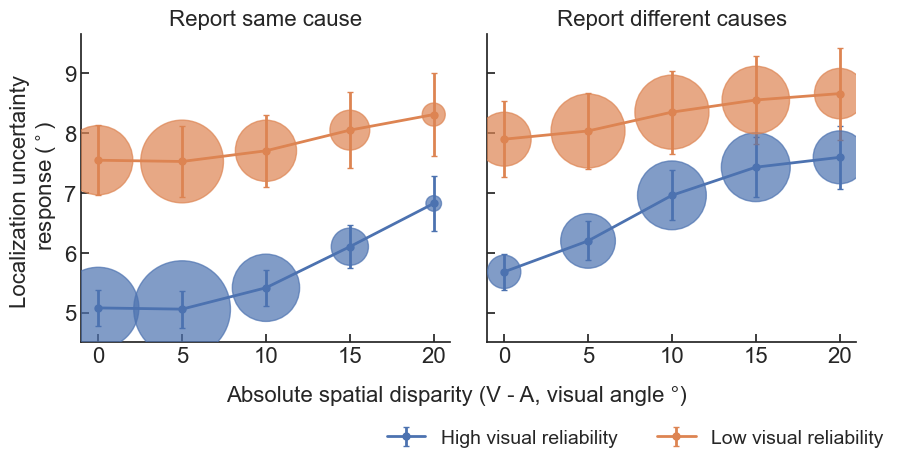

In [3]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==1], ax=axs[0])
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==2], ax=axs[1], legend=True)
axs[0].set_title('Report same cause', fontsize=fontsize)
axs[1].set_title('Report different causes', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
#plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

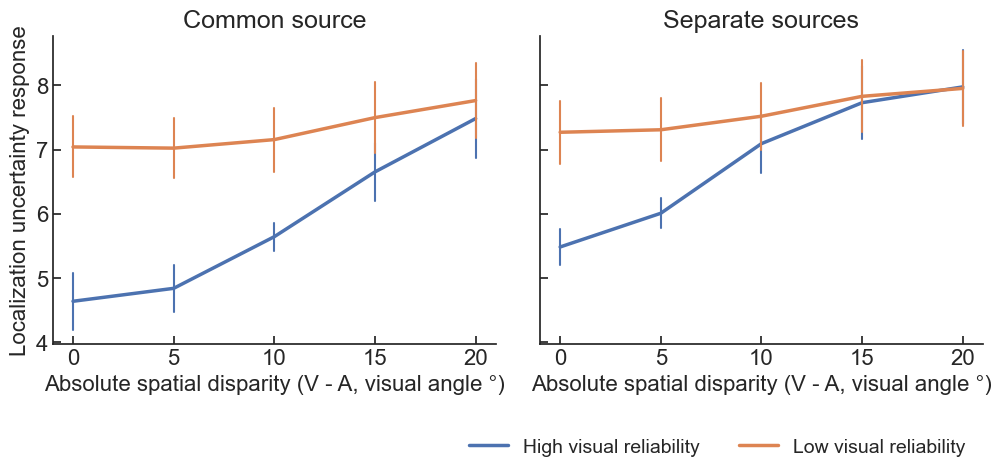

In [69]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==1], ax=axs[0])
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==2], ax=axs[1], legend='auto')
axs[0].set_title('Common source', fontsize=fontsize+2)
axs[1].set_title('Separate sources', fontsize=fontsize+2)
#add legend manually
handles, labels = axs[1].get_legend_handles_labels()
labels =[l + ' visual reliability' for l in labels]
axs[1].legend(handles, labels, loc='upper center', frameon=False, bbox_to_anchor=(0.4, -0.25), ncol=2, fontsize=fontsize-2)
#plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

## Causal inference

In [75]:
def scale_marker_size(n, global_min, global_max,
                      power=1, smin=50, smax=300):
    # first power then scale to make the trial counts difference more visible
    n = np.power(n, power)
    gmin_pw = np.power(global_min, power)
    gmax_pw = np.power(global_max, power)
    return (
        smin +
        (n - gmin_pw) /
        (gmax_pw - gmin_pw) *
        (smax - smin)
    )

In [76]:
df_plot = df_sim[(df_sim['Modality'] == 'A')]
all_summary_sub = (
    df_plot
    .groupby(["delta_VA", "sub_id", 'VisRelLabel', 'Sources'])
    .agg(n=('RespLoc', "size"))
    .reset_index()
)

all_summary = (
    all_summary_sub
    .groupby(["delta_VA", 'VisRelLabel', 'Sources'])
    .agg(n=("n", "sum"))
    .reset_index()
)

# power = 1.5
# global_n = np.power(all_summary["n"], power)

global_min = all_summary["n"].min()
global_max = all_summary["n"].max()
global_min, global_max

(np.int64(623), np.int64(34316))

In [77]:
def plot_casual_conf(df,ax, palette=palette_beh, trial_type=None, leg=False, scale=True):
    """
    Plot Confidence interval size/ causal confidence level / spatial report bias as a function of spatial disparities for different causal reports

    Parameters
    ----------
    df : pd.DataFrame
        processed data frame with CMB bias and lables.
    yvar : str
        the variable for examination. CISize/ConfLevel/bias.
    com_label : str
        Common/Separate/Total.
    trial_type : str
        'A' - auditory trials, 'V' - visual trials. Default None, which means both trial types are included.
    save_fig : bolen, optional
       The default is 0.
    Returns
    -------
    None.

    """
    trial_type_map = {'A':1, 'V':0}# 1 for auditory, 0 - for visual.
    if trial_type is not None:
        df = df[df.blockType==trial_type_map[trial_type]]

    #dfBySub = df.groupby(['sub_id', 'delta_VA', 'VisRelLabel'])['ConfLevel'].mean().reset_index()
    # helper fuction
    def plot_condition(df_cond, color,label):
         # Mean, SEM and total number of trials - two steps averaging
        summary_sub = (
            df_cond
            .groupby(["delta_VA", "sub_id"])
            .agg(
                mean=('ConfLevel', "mean"),
                #sem=(resp_var, "sem"),
                n=('ConfLevel', "size")
            )
            .reset_index()
            #.sort_values("AudLoc")
        )
        summary = (
            summary_sub
            .groupby(["delta_VA"])
            .agg(
                mean=('mean', "mean"),
                sem=('mean', "sem"),
                n=('n', "sum")
            )
            .reset_index()
            .sort_values("delta_VA")
        )

        if scale:
            summary["marker_size"] = scale_marker_size(summary["n"], global_min, global_max )
        else:
            summary["marker_size"] = summary["n"]
            
        ax.errorbar(
            summary["delta_VA"],
            summary["mean"],
            yerr=summary["sem"],
            color=color,
            linewidth=2,
            capsize=0,
            label=label,
            zorder=2,
            #alpha=0.7,
            marker='o',
            markersize=5,
        )
        ax.scatter(
                summary["delta_VA"],
                summary["mean"],
                s=summary["marker_size"], 
                color=color,
                # edgecolors="black",
                # linewidth=0.5,
                zorder=3,
                alpha=0.7,
            )
    plot_condition(
        df.loc[df.VisRelLabel == 'High'],
        color=palette['High'],
        label="High visual reliability"
    )
    plot_condition(
        df.loc[df.VisRelLabel == 'Low'],
        color=palette['Low'],
        label="Low visual reliability"
    )

    clean_axs(ax, fontsize=fontsize-2)  
    ax.set_xlabel('Spatial disparity, V - A ($^\circ$)', fontsize = fontsize)
    #ax.set_ylabel('Causal confidence (0-100)', fontsize = fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    if leg:
        ax.legend(
                frameon=False, 
                ncol = 2, 
                loc = 'upper right', 
                bbox_to_anchor=(0.8, -0.2), 
                fontsize = fontsize-2)


Text(0, 0.5, 'Causal confidence (0-100)')

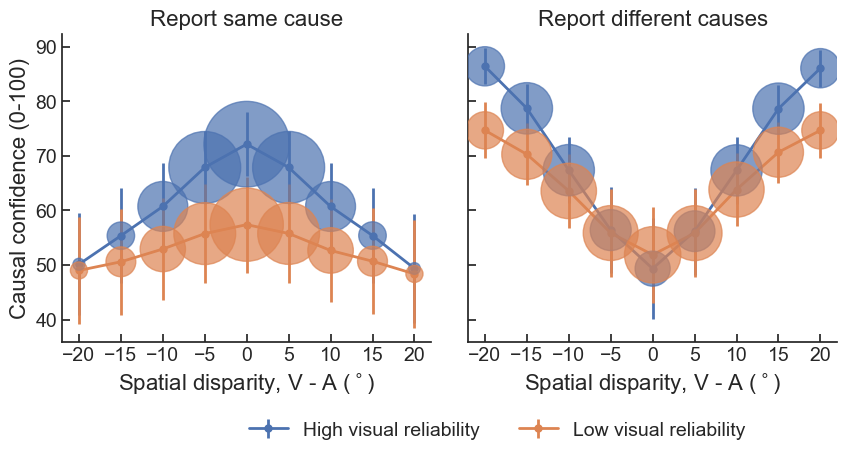

In [3]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_sim.loc[df_sim.Sources==1],ax=axs[0], scale=False,
                 #trial_type='A', 
                 leg=False)
plot_casual_conf(df=df_sim.loc[df_sim.Sources==2],ax=axs[1], scale=False,
                 #trial_type='A', 
                 leg=True)

axs[0].set_title('Report same cause', fontsize=fontsize, y=1)
axs[1].set_title('Report different causes', fontsize=fontsize, y=1)
axs
axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
#fig.savefig(os.path.join(plot_path, "causal_conf_beh.png"), dpi=300, bbox_inches="tight")

### Formal model comparison

In [21]:
exp_name1, exp_name2 = 'test_causal_bin1', 'with_dn'
CM=CompareModels(exp_name1, exp_name2)
m_lst= [2]

In [22]:
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')

In [23]:
df_ev

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,test_causal_bin1,2,37568.566724,37568.738785,37649.854774,18770.283362,14,"[1.326134351452349, 4.650853633880615, 4.64873...",QML,BayInt,MS,Bay
1,2,test_causal_bin1,3,35324.544129,35324.719202,35405.590695,17648.272065,14,"[1.0045600873260956, 3.6532156467437744, 5.579...",QML,BayInt,MS,Bay
2,2,test_causal_bin1,5,35605.052149,35605.226930,35686.121893,17788.526074,14,"[1.7991667350174971, 4.258444547653198, 3.9422...",QML,BayInt,MS,Bay
3,2,test_causal_bin1,6,34258.787898,34258.962680,34339.857643,17115.393949,14,"[1.4439854756012767, 1.755759835243225, 3.3877...",QML,BayInt,MS,Bay
4,2,test_causal_bin1,11,35646.966846,35647.141409,35728.053949,17809.483423,14,"[1.079057272269894, 3.7007843255996704, 4.2345...",QML,BayInt,MS,Bay
5,2,test_causal_bin1,15,38115.504884,38115.676733,38196.810024,19043.752442,14,"[0.5902048433094178, 6.306135773658752, 6.2475...",QML,BayInt,MS,Bay
6,2,test_causal_bin1,20,34270.218675,34270.394775,34351.183811,17121.109337,14,"[0.9323276798160927, 2.7525576651096344, 5.001...",QML,BayInt,MS,Bay
7,2,test_causal_bin1,25,39009.191750,39009.364518,39090.422680,19490.595875,14,"[0.45784243104317845, 1.666839599609375, 4.490...",QML,BayInt,MS,Bay
8,2,with_dn,2,35779.248434,35779.445155,35866.342773,17874.624217,15,"[2.021700377847035, 6.817628875374794, 5.20707...",QML,BayInt,MS,Bay
9,2,with_dn,3,35409.843480,35410.043647,35496.679086,17689.921740,15,"[3.508105432502043, 6.77004337310791, 5.177550...",QML,BayInt,MS,Bay


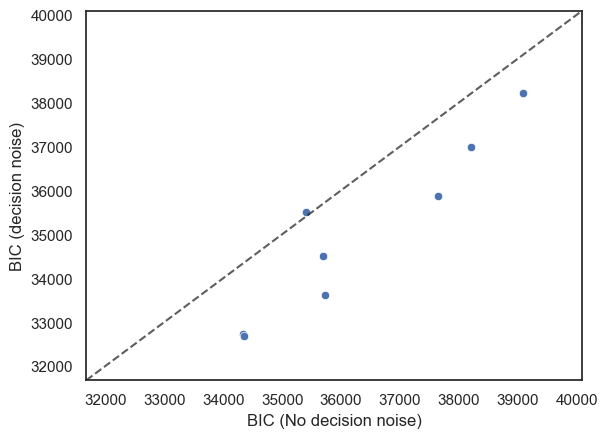

In [25]:
# two models comparison plot BIC aganist BIC
sns.scatterplot(x=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True), y=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name2), 'BIC'].reset_index(drop=True))
lims = [
    df_ev.BIC.min()-1000,  # lowest value across both
    df_ev.BIC.max()+1000   # highest value across both
]
plt.xlim(lims)
plt.ylim(lims)

# Add diagonal y=x line
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("BIC (No decision noise)")
plt.ylabel("BIC (decision noise)")

plt.show()